<a href="https://colab.research.google.com/github/Habiba-Arafa/optimizer-showdown/blob/main/Custom_Neural_Network_Optimizers_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import OneHotEncoder

# Loading the MNIST dataset

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()


# Flattening the images and normalizing the pixeles


In [ ]:
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

# One-hot encode labels

In [ ]:
encoder = OneHotEncoder(sparse_output=False)


In [ ]:
y_train = encoder.fit_transform(y_train.reshape(-1, 1))
y_test = encoder.transform(y_test.reshape(-1, 1))

# intializing the Neural network hyperparameters

In [ ]:
input_size = 784
hidden_size = 128
output_size = 10

# Initializing the weights and biases for the neural network layers


In [ ]:
np.random.seed(0)


In [ ]:
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

In [ ]:
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

# creating the activation function

In [ ]:

def relu(Z):
    return np.maximum(0, Z)


In [ ]:

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)

# creating function to compute cross entropy loss for classification

In [ ]:
def compute_loss(y_true, y_pred):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

# building the forward propagation function


In [ ]:
def forward(X, W1, b1, W2, b2):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

# building the backward propagation function


In [ ]:
def backward(X, y_true, Z1, A1, Z2, A2, W1, W2):
    m = X.shape[0]
    dZ2 = A2 - y_true
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * (Z1 > 0)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m
    return dW1, db1, dW2, db2

# Creating  the SGD optimizer


In [ ]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for p, g in zip(params, grads):
            p -= self.lr * g

#Creatig the RMSProp

In [ ]:
class RMSProp:
    def __init__(self, lr=0.001, beta=0.9, epsilon=1e-8):
        self.lr = lr
        self.beta = beta
        self.epsilon = epsilon
        self.sq_grads = None

    def update(self, params, grads):
        if self.sq_grads is None:
            self.sq_grads = [np.zeros_like(g) for g in grads]

        for i, (p, g) in enumerate(zip(params, grads)):
            self.sq_grads[i] = self.beta * self.sq_grads[i] + (1 - self.beta) * g**2
            p -= self.lr * g / (np.sqrt(self.sq_grads[i]) + self.epsilon)

# Creting the Adam optimizer


In [ ]:
class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = None
        self.v = None
        self.t = 0

    def update(self, params, grads):
        if self.m is None:
            self.m = [np.zeros_like(g) for g in grads]
            self.v = [np.zeros_like(g) for g in grads]

        self.t += 1
        for i, (p, g) in enumerate(zip(params, grads)):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g**2)

            m_hat = self.m[i] / (1 - self.beta1**self.t)
            v_hat = self.v[i] / (1 - self.beta2**self.t)

            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)


# Creting the AdaGrad optimizer


In [ ]:
class AdaGrad:
    def __init__(self, lr=0.01, epsilon=1e-8):
        self.lr = lr
        self.epsilon = epsilon
        self.sumsq = None

    def update(self, params, grads):
        if self.sumsq is None:
            self.sumsq = [np.zeros_like(g) for g in grads]

        for i, (p, g) in enumerate(zip(params, grads)):
            self.sumsq[i] += g ** 2
            p -= self.lr * g / (np.sqrt(self.sumsq[i]) + self.epsilon)


# Creting the AdaDelta optimizer


In [ ]:
import numpy as np

class AdaDelta:
    def __init__(self, lr=1.0, decay_rate=0.95, epsilon=1e-6):
        self.lr = lr
        self.decay_rate = decay_rate
        self.epsilon = epsilon
        self.accumulated_grads = None
        self.accumulated_updates = None
        self.t = 0

    def update(self, params, grads):
        if self.accumulated_grads is None:
            self.accumulated_grads = [np.zeros_like(g) for g in grads]
            self.accumulated_updates = [np.zeros_like(g) for g in grads]

        self.t += 1

        for i, (p, g) in enumerate(zip(params, grads)):
            self.accumulated_grads[i] = self.decay_rate * self.accumulated_grads[i] + (1 - self.decay_rate) * (g**2)
            update = np.sqrt(self.accumulated_updates[i] + self.epsilon) / np.sqrt(self.accumulated_grads[i] + self.epsilon) * g
            p -= update
            self.accumulated_updates[i] = self.decay_rate * self.accumulated_updates[i] + (1 - self.decay_rate) * (update**2)




# Definig the training function for the optimzers

In [ ]:
def train(optimizer, epochs=10, batch_size=64):
    global W1, b1, W2, b2
    losses = []
    for epoch in range(epochs):
        for i in range(0, X_train.shape[0], batch_size):
            X_batch = X_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]

            Z1, A1, Z2, A2 = forward(X_batch, W1, b1, W2, b2)
            dW1, db1, dW2, db2 = backward(X_batch, y_batch, Z1, A1, Z2, A2, W1, W2)

            optimizer.update([W1, b1, W2, b2], [dW1, db1, dW2, db2])


        _, _, _, A2 = forward(X_train, W1, b1, W2, b2)
        loss = compute_loss(y_train, A2)
        losses.append(loss)
        print(f"Epoch {epoch + 1}, Loss: {loss:.4f}")
    return losses


# Comparing optimizers


In [ ]:
sgd_optimizer = SGD(lr=0.01)


In [ ]:
rmsprop_optimizer = RMSProp(lr=0.001)


In [ ]:
adam_optimizer = Adam(lr=0.0001)


In [ ]:
ada_grad_optimizer = AdaGrad(lr=0.001)


In [ ]:
ada_delta_optimizer = AdaDelta(lr=0.001)

In [ ]:
print("Training with SGD:")
sgd_losses = train(sgd_optimizer)

Training with SGD:
Epoch 1, Loss: 1.0246
Epoch 2, Loss: 0.5317
Epoch 3, Loss: 0.4186
Epoch 4, Loss: 0.3711
Epoch 5, Loss: 0.3441
Epoch 6, Loss: 0.3255
Epoch 7, Loss: 0.3113
Epoch 8, Loss: 0.2993
Epoch 9, Loss: 0.2886
Epoch 10, Loss: 0.2788


In [ ]:
print("Training with adagrad:")

ada_grad_losses = train(ada_grad_optimizer)

Training with adagrad:
Epoch 1, Loss: 0.2579
Epoch 2, Loss: 0.2500
Epoch 3, Loss: 0.2443
Epoch 4, Loss: 0.2396
Epoch 5, Loss: 0.2356
Epoch 6, Loss: 0.2320
Epoch 7, Loss: 0.2288
Epoch 8, Loss: 0.2260
Epoch 9, Loss: 0.2233
Epoch 10, Loss: 0.2208


In [ ]:
print("Training with RMSProp:")
rmsprop_losses = train(rmsprop_optimizer)


Training with RMSProp:
Epoch 1, Loss: 0.1414
Epoch 2, Loss: 0.0989
Epoch 3, Loss: 0.0795
Epoch 4, Loss: 0.0676
Epoch 5, Loss: 0.0587
Epoch 6, Loss: 0.0501
Epoch 7, Loss: 0.0463
Epoch 8, Loss: 0.0428
Epoch 9, Loss: 0.0385
Epoch 10, Loss: 0.0360


In [ ]:

print("Training with Adam:")
adam_losses = train(adam_optimizer)

Training with Adam:
Epoch 1, Loss: 0.0007
Epoch 2, Loss: 0.0005
Epoch 3, Loss: 0.0005
Epoch 4, Loss: 0.0004
Epoch 5, Loss: 0.0004
Epoch 6, Loss: 0.0004
Epoch 7, Loss: 0.0003
Epoch 8, Loss: 0.0003
Epoch 9, Loss: 0.0003
Epoch 10, Loss: 0.0002


In [ ]:
print("Training with ada_delta:")
ada_delta_losses = train(ada_delta_optimizer)

Training with ada_delta:
Epoch 1, Loss: 0.0041
Epoch 2, Loss: 0.0028
Epoch 3, Loss: 0.0021
Epoch 4, Loss: 0.0017
Epoch 5, Loss: 0.0013
Epoch 6, Loss: 0.0011
Epoch 7, Loss: 0.0009
Epoch 8, Loss: 0.0008
Epoch 9, Loss: 0.0007
Epoch 10, Loss: 0.0006


In [ ]:
import plotly.graph_objects as go


In [ ]:
fig = go.Figure()


In [ ]:
fig.add_trace(go.Scatter(
    y=sgd_losses,
    mode='lines+markers',
    name='SGD'
))

In [ ]:
fig.add_trace(go.Scatter(
    y=ada_grad_losses,
    mode='lines+markers',
    name='AdaGrad'
))

In [ ]:
fig.add_trace(go.Scatter(
    y=ada_delta_losses,
    mode='lines+markers',
    name='AdaDelta'
))

In [ ]:
fig.add_trace(go.Scatter(
    y=rmsprop_losses,
    mode='lines+markers',
    name='RMSProp'
))

In [ ]:
fig.add_trace(go.Scatter(
    y=adam_losses,
    mode='lines+markers',
    name='Adam'
))

In [ ]:
fig.update_layout(
    title='Loss Comparison of Optimizers',
    xaxis_title='Epochs',
    yaxis_title='Loss',
    legend_title='Optimizers',
    template='plotly_white'
)
fig.show()


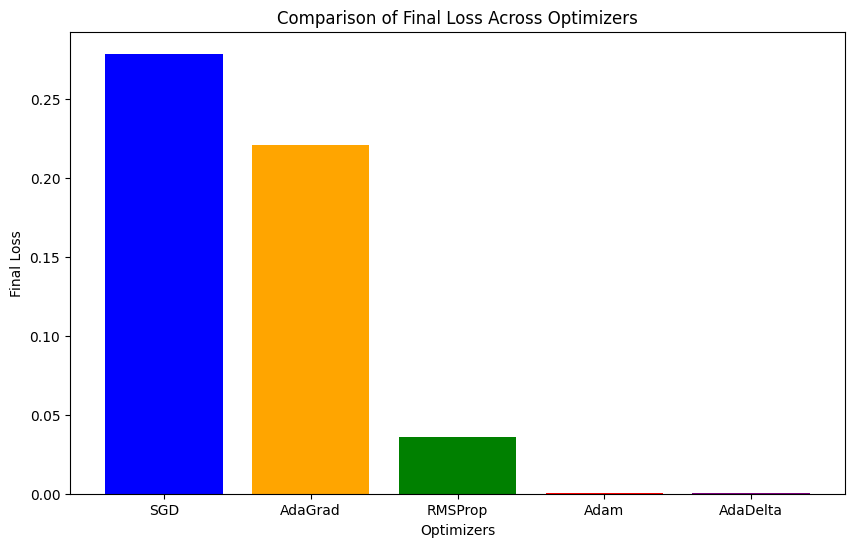

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

optimizers = ['SGD', 'AdaGrad', 'RMSProp', 'Adam', 'AdaDelta']

final_losses = [
    sgd_losses[-1],
    ada_grad_losses[-1],
    rmsprop_losses[-1],
    adam_losses[-1],
    ada_delta_losses[-1]
]

plt.figure(figsize=(10, 6))
plt.bar(optimizers, final_losses, color=['blue', 'orange', 'green', 'red', 'purple'])
plt.xlabel('Optimizers')
plt.ylabel('Final Loss')
plt.title('Comparison of Final Loss Across Optimizers')
plt.show()


# Applying  the same optimizers with the same approach but with built in functions

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()


In [ ]:

X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

In [ ]:
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [ ]:
def create_model(optimizer):
    model = Sequential([
        Dense(128, input_shape=(784,), activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
rmsprop_optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001)


In [ ]:
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)


In [ ]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)


In [ ]:
rmsprop_optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001)


In [ ]:
adagrad_optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.001)


In [ ]:
adadelta_optimizer = tf.keras.optimizers.Adadelta(learning_rate=0.001)


In [ ]:
history = {}

In [ ]:
print("Training with SGD:")
model_sgd = create_model(sgd_optimizer)
history['SGD'] = model_sgd.fit(X_train, y_train, epochs=10, batch_size=64, verbose=1).history['loss']

Training with SGD:
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6428 - loss: 1.3418
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8818 - loss: 0.4479
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8970 - loss: 0.3698
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9080 - loss: 0.3302
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9141 - loss: 0.3064
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9202 - loss: 0.2847
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9223 - loss: 0.2710
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9260 - loss: 0.2597
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9314 - loss: 0.2457
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9334 - loss: 0.2324


In [ ]:
print("Training with RMSProp:")
model_rmsprop = create_model(rmsprop_optimizer)
history['RMSProp'] = model_rmsprop.fit(X_train, y_train, epochs=10, batch_size=64, verbose=1).history['loss']

Training with RMSProp:
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8675 - loss: 0.4817
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9562 - loss: 0.1516
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9708 - loss: 0.1007
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9786 - loss: 0.0726
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9819 - loss: 0.0619
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9843 - loss: 0.0520
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9874 - loss: 0.0415
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9895 - loss: 0.0353
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9906 - loss: 0.0313
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9923 - loss: 0.0267


In [ ]:
print("Training with Adam:")
model_adam = create_model(adam_optimizer)
history['Adam'] = model_adam.fit(X_train, y_train, epochs=10, batch_size=64, verbose=1).history['loss']

Training with Adam:
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8627 - loss: 0.4952
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9583 - loss: 0.1432
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9717 - loss: 0.0967
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9793 - loss: 0.0714
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9846 - loss: 0.0533
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9876 - loss: 0.0426
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9910 - loss: 0.0329
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9921 - loss: 0.0274
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9930 - loss: 0.0230
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9953 - loss: 0.0186


In [ ]:
print("Training with :AdaGrad")
model_adagrad = create_model(adagrad_optimizer)
history['AdaGrad'] = model_adagrad.fit(X_train, y_train, epochs=10, batch_size=64, verbose=1).history['loss']

Training with Adam:


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4781 - loss: 1.8161
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8221 - loss: 0.8680
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8523 - loss: 0.6461
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8679 - loss: 0.5545
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8779 - loss: 0.4956
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8827 - loss: 0.4625
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8892 - loss: 0.4338
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8922 - loss: 0.4146
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8931 - loss: 0.4050
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8965 - loss: 0.3891


In [ ]:
print("Training with AdaDelta:")
model_adagrad = create_model(adadelta_optimizer)
history['AdaDelta'] = model_adagrad.fit(X_train, y_train, epochs=10, batch_size=64, verbose=1).history['loss']

Training with AdaDelta:
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1116 - loss: 2.3459
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2082 - loss: 2.2280
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3013 - loss: 2.1207
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3751 - loss: 2.0181
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4469 - loss: 1.9134
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5121 - loss: 1.8115
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5705 - loss: 1.7163
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6284 - loss: 1.6248
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6754 - loss: 1.5344
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7052 - loss: 1.4455


In [ ]:
for optimizer, losses in history.items():
    if not any(trace.name == optimizer for trace in fig.data):
        fig.add_trace(go.Scatter(
            y=losses,
            mode='lines+markers',
            name=optimizer
        ))

In [ ]:



fig.update_layout(
    title='Loss Comparison of Optimizers (Keras)',
    xaxis_title='Epochs',
    yaxis_title='Loss',
    legend_title='Optimizers',
    template='plotly_white'
)

fig.show()


In [ ]:
final_losses = {optimizer: losses[-1] for optimizer, losses in history.items()}

fig = go.Figure()
fig.add_trace(go.Bar(
    x=list(final_losses.keys()),
    y=list(final_losses.values()),
    name='Final Loss'
))

fig.update_layout(
    title='Final Loss Comparison of Optimizers (Keras)',
    xaxis_title='Optimizer',
    yaxis_title='Final Loss',
    template='plotly_white'
)
fig.show()